# 第1回 — キックオフ + PyTorch 基礎 + data

このノートブックは KWS（keyword spotting）チュートリアルの第1回．題材は torchaudio の
`SPEECHCOMMANDS`（35 クラスの音声コマンド認識）．

**今日のゴール**：`DataLoader` を回すと **log-mel スペクトログラムのミニバッチ `(B, 1, n_mels, T')`** が
出てくるのを，自分の手で動かして確認する — `check_data` が PASS すれば完成．

進め方：上から順にセルを実行し，**`# TODO` のセルを埋めて**動かす．
最後に，埋めたコードを `src/kws/data.py` に整理する（宿題）．

参考リンク：
- PyTorch "Learn the Basics"（英語）: https://docs.pytorch.org/tutorials/beginner/basics/intro.html
- PyTorch チュートリアル日本語訳: https://yutaroogawa.github.io/pytorch_tutorials_jp/
- torchaudio `SPEECHCOMMANDS`: https://docs.pytorch.org/audio/stable/generated/torchaudio.datasets.SPEECHCOMMANDS.html

In [1]:
# プロジェクトルートで動かす前提（notebooks/ から開いても data/ や src/ を相対参照できるように）
import os
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("cwd:", Path.cwd())

cwd: /home/ymgt/ShiotaLab/B4_rinko_torchaudio


## ハンズオン①：PyTorch 基礎（15分）

Tensor の `shape`・`dtype`・`device`，`squeeze`/`unsqueeze`，`.to()` を手で触る．
ここは概念確認なので**動く例をそのまま実行**してよい．

In [2]:
import torch

# Tensor を作る・形を見る
x = torch.randn(2, 3)
print("x =", x)
print("shape:", x.shape, "| dtype:", x.dtype, "| device:", x.device)

x = tensor([[ 1.6322, -1.2787,  0.6813],
        [ 1.7078, -0.3546,  0.8376]])
shape: torch.Size([2, 3]) | dtype: torch.float32 | device: cpu


In [3]:
# dtype の違い：整数リストから作ると int64（long）になる
a = torch.tensor([1, 2, 3])
b = torch.tensor([1.0, 2.0, 3.0])
print("int Tensor dtype:", a.dtype)    # torch.int64
print("float Tensor dtype:", b.dtype)  # torch.float32
# 後でラベルは torch.long（=torch.int64）にする，その伏線

int Tensor dtype: torch.int64
float Tensor dtype: torch.float32


In [4]:
# squeeze / unsqueeze — サイズ 1 の次元を消す / 足す
# torchaudio が返す waveform は (1, T) の shape
waveform_2d = torch.randn(1, 16000)   # (channels=1, samples)
print("元の shape:", waveform_2d.shape)

w1d = waveform_2d.squeeze(0)          # (16000,)  — チャンネル次元を消す
print("squeeze(0):", w1d.shape)

w_ch = w1d.unsqueeze(0)               # (1, 16000) — チャンネル次元を足す
print("unsqueeze(0):", w_ch.shape)

# ③ で collate_fn の中で waveform.squeeze(0) と feats.unsqueeze(1) を使う（布石）
batch = torch.randn(8, 64, 101)        # (B, n_mels, T') — log-mel バッチ
print("channel を足す前:", batch.shape)
print("unsqueeze(1) 後:", batch.unsqueeze(1).shape)  # (B, 1, n_mels, T')

元の shape: torch.Size([1, 16000])
squeeze(0): torch.Size([16000])
unsqueeze(0): torch.Size([1, 16000])
channel を足す前: torch.Size([8, 64, 101])
unsqueeze(1) 後: torch.Size([8, 1, 64, 101])


In [5]:
# device：CPU / GPU 間の移動
dev = "cuda" if torch.cuda.is_available() else "cpu"
print("使う device:", dev)

x_cpu = torch.randn(4, 4)
x_dev = x_cpu.to(dev)
print("moved to:", x_dev.device)

# 同じ device に揃えないと演算エラーになる（モデルとデータは同じ device に置く）
import torchaudio
print("\ntorch:", torch.__version__)
print("torchaudio:", torchaudio.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

使う device: cuda
moved to: cuda:0



torch: 2.4.1+cu121
torchaudio: 2.4.1+cu121
CUDA available: True
device name: NVIDIA GeForce RTX 3090


## ハンズオン②：data を見る（15分）

torchaudio の `SPEECHCOMMANDS` を触り，データを目で見る．
ここも API の確認なので**動く例を実行するだけ**でよい．

In [6]:
import torchaudio
import os

os.makedirs("data", exist_ok=True)
# 事前課題でダウンロード済みのため download=False
ds = torchaudio.datasets.SPEECHCOMMANDS(root="data", download=False, subset="training")
print("num samples (training):", len(ds))

waveform, sr, label, speaker_id, utterance_number = ds[0]
print("waveform shape:", waveform.shape, "| sample_rate:", sr, "| label:", label)
print("speaker_id:", speaker_id, "| utterance_number:", utterance_number)

num samples (training): 84843
waveform shape: torch.Size([1, 16000]) | sample_rate: 16000 | label: backward
speaker_id: 0165e0e8 | utterance_number: 0


/home/ymgt/ShiotaLab/B4_rinko_torchaudio/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


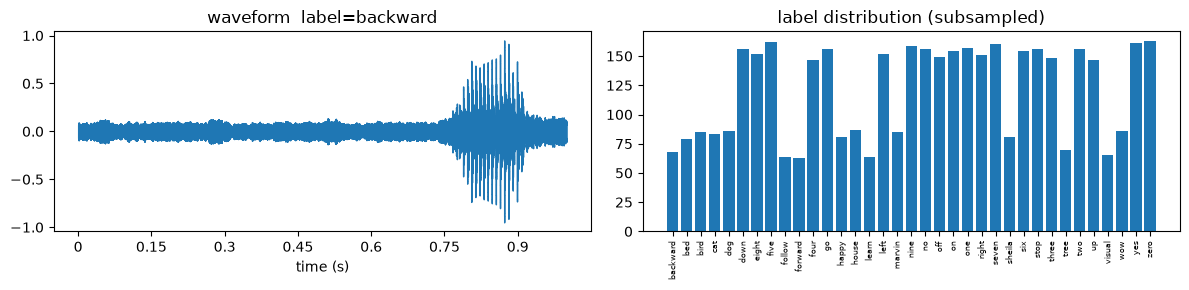

In [7]:
# 波形を見る（librosa.display.waveshow で時間軸が秒表記になる）
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# 波形
ax = axes[0]
librosa.display.waveshow(waveform.squeeze(0).numpy(), sr=sr, ax=ax)
ax.set_title(f"waveform  label={label}")
ax.set_xlabel("time (s)")

# クラス分布（間引いてカウント）
from collections import Counter
ax2 = axes[1]
sample_labels = [ds[i][2] for i in range(0, len(ds), 20)]
cnt = Counter(sample_labels)
keys = sorted(cnt)
ax2.bar(range(len(keys)), [cnt[k] for k in keys])
ax2.set_xticks(range(len(keys)))
ax2.set_xticklabels(keys, rotation=90, fontsize=6)
ax2.set_title("label distribution (subsampled)")

fig.tight_layout()
plt.show()

log-mel shape: torch.Size([1, 64, 101])


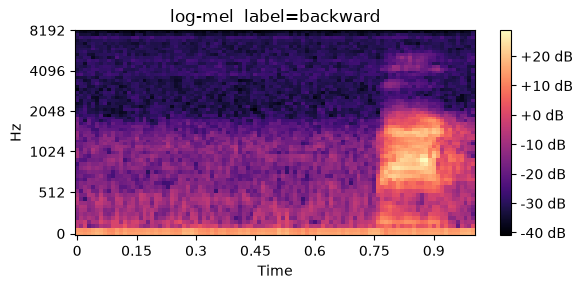

In [8]:
# log-mel スペクトログラム：make_logmel 関数
import torchaudio.transforms as T
from torch import nn

SAMPLE_RATE = 16000

def make_logmel(sample_rate: int = SAMPLE_RATE, n_mels: int = 64) -> nn.Module:
    return nn.Sequential(
        T.MelSpectrogram(sample_rate=sample_rate, n_fft=400, hop_length=160, n_mels=n_mels),
        T.AmplitudeToDB(),
    )

logmel = make_logmel(n_mels=64)

# 1サンプルに適用して形を確認（waveform は (1,T) → (1,n_mels,T')）
spec = logmel(waveform)   # (1, 64, T')
print("log-mel shape:", spec.shape)

fig, ax = plt.subplots(figsize=(6, 3))
librosa.display.specshow(
    spec.squeeze(0).numpy(), sr=sr, hop_length=160,
    x_axis="time", y_axis="mel", ax=ax, cmap="magma"
)
ax.set_title(f"log-mel  label={label}")
plt.colorbar(ax.collections[0], ax=ax, format="%+2.0f dB")
plt.tight_layout()
plt.show()

In [9]:
# label ↔ index の対応
# 35 クラスをアルファベット順で固定する（環境に依らず同じ index になる）
LABELS = [
    "backward", "bed", "bird", "cat", "dog", "down", "eight", "five", "follow", "forward",
    "four", "go", "happy", "house", "learn", "left", "marvin", "nine", "no", "off",
    "on", "one", "right", "seven", "sheila", "six", "stop", "three", "tree", "two",
    "up", "visual", "wow", "yes", "zero",
]
label_to_index = {label: i for i, label in enumerate(LABELS)}
index_to_label = {i: label for i, label in enumerate(LABELS)}

print("num classes:", len(LABELS))
print("yes ->", label_to_index["yes"], "| index 0 ->", index_to_label[0])
# ラベルは整数 index に変換して CrossEntropyLoss に渡す（第3回への伏線）

num classes: 35
yes -> 33 | index 0 -> backward


## ハンズオン③：data を束ねる（25分）

ここが今日の**手を動かす中心**．

`DataLoader` はサンプルのリストをバッチテンソルに変換するための `collate_fn` を受け取る．
波形は長さがバラバラなので，先に **1秒 = 16000 サンプル** に揃えてから stack する必要がある．

### 流れ
1. `pad_or_trim`：波形を 16000 サンプルに揃える
2. `make_collate_fn`：「揃える → stack → log-mel → (B,1,n_mels,T')」を一括でやる関数

**詰まったときの中間チェック**：
- `pad_or_trim(torch.zeros(5000)).shape` → `torch.Size([16000])`
- `pad_or_trim(torch.zeros(30000)).shape` → `torch.Size([16000])`
- collate で 1 バッチ取り出して `feats.shape` が `(8, 1, 64, 101)` になるか確認

In [10]:
NUM_SAMPLES = 16000  # 1 秒ぶん（16kHz × 1s）

In [11]:
def pad_or_trim(waveform: torch.Tensor, num_samples: int = NUM_SAMPLES) -> torch.Tensor:
    """1次元波形を num_samples ちょうどに揃える（短ければ末尾を 0 パディング，長ければ切り詰め）."""
    n = waveform.shape[-1]
    if n < num_samples:
        waveform = torch.nn.functional.pad(waveform, (0, num_samples - n))
    elif n > num_samples:
        waveform = waveform[..., :num_samples]
    return waveform

# 動作確認
print(pad_or_trim(torch.zeros(5000)).shape)   # -> torch.Size([16000])
print(pad_or_trim(torch.zeros(30000)).shape)  # -> torch.Size([16000])

torch.Size([16000])
torch.Size([16000])


In [12]:
def make_collate_fn(transform: nn.Module):
    """DataLoader 用の collate_fn を作る．
    各サンプル (waveform, sr, label, ...) を
    1) 1秒に揃える  2) stack して (B, T)  3) log-mel + channel 次元追加 (B, 1, n_mels, T')
    に変換し，ラベルは index の LongTensor にして返す．
    """
    def collate(batch):
        waveforms, targets = [], []
        for waveform, _sr, label, *_ in batch:
            waveforms.append(pad_or_trim(waveform.squeeze(0)))  # (1,T) -> (T,) -> (16000,)
            targets.append(label_to_index[label])
        waveforms = torch.stack(waveforms)           # (B, T)
        feats = transform(waveforms).unsqueeze(1)    # (B, n_mels, T') -> (B, 1, n_mels, T')
        targets = torch.tensor(targets, dtype=torch.long)
        return feats, targets
    return collate

### DataLoader で1バッチ取り出す

In [13]:
from torch.utils.data import DataLoader

collate = make_collate_fn(make_logmel(n_mels=64))
# num_workers=0 にする（Jupyter で num_workers>0 はハングの定番地雷）
loader = DataLoader(ds, batch_size=8, shuffle=True, num_workers=0, collate_fn=collate)

feats, targets = next(iter(loader))
print("feats:", feats.shape, feats.dtype)     # -> (8, 1, 64, 101)
print("targets:", targets.shape, targets.dtype)
print("ラベル例:", [index_to_label[i.item()] for i in targets])

feats: torch.Size([8, 1, 64, 101]) torch.float32
targets: torch.Size([8]) torch.int64
ラベル例: ['no', 'yes', 'stop', 'down', 'tree', 'happy', 'wow', 'off']


### check_data（PASS すれば data 完成）

`check_data` が PASS すれば今日のゴール達成．

In [14]:
# check_data：1バッチが規定の shape / dtype / 範囲で出るか assert する
# torch.long は torch.int64 の別名（同じ型）

N_MELS, NUM_SAMPLES_CHECK = 64, 16000

# pad_or_trim 単体テスト
assert pad_or_trim(torch.zeros(5000)).shape[-1] == NUM_SAMPLES_CHECK,   "短い→パディング失敗"
assert pad_or_trim(torch.zeros(30000)).shape[-1] == NUM_SAMPLES_CHECK,  "長い→切り詰め失敗"

# 1バッチを取り出して検証
loader_check = DataLoader(ds, batch_size=8, collate_fn=collate, num_workers=0)
feats, labels = next(iter(loader_check))

assert feats.shape == (8, 1, N_MELS, 101), f"shape mismatch: {feats.shape}"  # T'=16000//160+1=101
assert feats.dtype == torch.float32, feats.dtype
assert labels.dtype == torch.long, labels.dtype          # == torch.int64
assert int(labels.min()) >= 0 and int(labels.max()) <= 34, (labels.min().item(), labels.max().item())
assert not torch.isnan(feats).any() and not torch.isinf(feats).any(), "NaN or Inf in feats"

# ラベル数の確認
assert len(LABELS) == 35, f"LABELS should have 35 entries, got {len(LABELS)}"

print("check_data PASS:", tuple(feats.shape), labels.dtype)
# 期待出力: check_data PASS: (8, 1, 64, 101) torch.int64

check_data PASS: (8, 1, 64, 101) torch.int64


## まとめ

今日は notebook の中だけで `DataLoader` から `(B, 1, n_mels, T')` のミニバッチが出るところまで作った．

### import の動機づけ（宿題の前置き）

今日は1つのノートブックに全部書いたが，コードをファイルに分けて `import` で集めると見通しが良くなる．
だから次回までに，今日書いたコードを `src/kws/data.py` に整理する．

```python
# 宿題の確認スクリプトで使う import の形
import sys
sys.path.insert(0, "src")
from kws.data import LABELS, label_to_index, pad_or_trim, make_logmel, make_collate_fn
```

### 宿題

1. **`src/kws/data.py` に移植**：今日 notebook で書いたコードをまとめ，`check_data` を PASS させる
2. **第2回（model）の予習**：`nn.Module` の書き方 / `Conv2d` / `BatchNorm2d` を読んでくる
3. 「分かったこと1点 + 疑問1点」を持ち寄る

詰まったときは遠慮なく指導者に相談すること．

### 次回

data が出す `(B, 1, n_mels, T')` が，第2回で作る **AudioCNN** の入力になる．